# 01 · Eksplorasi Data Coastal Squeeze Mangrove Pantura Jawa

Notebook ini **hanya memeriksa data**: apa isinya, seberapa lengkap, seberapa konsisten antar-sumber, dan masalah apa
yang harus ditangani analisis. Tidak ada model atau rekomendasi di sini; semuanya ada di
[`02_Analisis_Coastal_Squeeze.ipynb`](02_Analisis_Coastal_Squeeze.ipynb).

Kedua notebook **independen**: masing-masing membaca data mentah di `code/dataset/` lewat modul pemuat bersama
[`muat_data.py`](muat_data.py) dan tidak membaca keluaran notebook lain. Keluaran notebook ini disimpan di
`analisis/hasil/eksplorasi/`.

## Pertanyaan yang dijawab

| Bagian | Pertanyaan |
|---|---|
| 2 | Data apa yang tersedia, berapa dimensinya, dan apakah kuncinya konsisten? |
| 3 | Di mana dan **mengapa** data kosong? |
| 4 | Apakah sinyal satelit (NDVI, VH) bisa membedakan mangrove dari kelas lahan lain? |
| 5 | Seberapa konsisten tiga sumber mangrove (WorldCover, GMW, Sentinel), dan bagaimana mangrove berubah 1985–2025? |
| 6 | Bagaimana sebaran dan keandalan data tekanan (amblesan, penghalang, penduduk)? |
| 7 | Seperti apa lahan di belakang garis pantai (tambak) dan bagaimana berubah 2021–2026? |
| 8 | Bagaimana pola genangan pasang-surut di tiap jenis lahan? |
| 9 | **Daftar masalah data** dan di bagian mana notebook analisis menanganinya |

## 1. Setup

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import muat_data as md

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)

HASIL = md.CODE / "analisis" / "hasil" / "eksplorasi"
HASIL.mkdir(parents=True, exist_ok=True)
REG, REG_NAMA, BULAN, T, TAHUN, TH_T = md.REG, md.REG_NAMA, md.BULAN, md.T, md.TAHUN, md.TH_T
STEP, LEN_SEA, P, DIST, KELAS_DW, TAHUN_GMW = md.STEP, md.LEN_SEA, md.P, md.DIST, md.KELAS_DW, md.TAHUN_GMW
REG_WARNA = dict(zip(REG, sns.color_palette("tab10", 5)))
JMAX = 1500 // STEP + 1   # zona pesisir untuk keberadaan mangrove: dist_m 0-1.500 (s.d. 1 km di belakang garis pantai basis)

def simpan(nama):
    plt.savefig(HASIL / f"{nama}.png", dpi=130, bbox_inches="tight")

def tabel(df, nama):
    df.to_csv(HASIL / f"{nama}.csv"); return df

def ada_rangkaian(M, run=3, jmax=JMAX):
    # True per transek bila ada >= run titik berturut-turut (30 m) bernilai True dalam dist_m 0..jmax
    M = M[:, :jmax].astype(np.int8)
    k = sum(M[:, i: jmax - run + 1 + i] for i in range(run))
    return (k == run).any(1)

t0 = time.time()
Z = md.tensor_profil(); IDS = Z["ids"]; N = len(IDS)
NDVI, MNDWI, NOBS, VV, VH, DW = (Z[k] for k in ["NDVI", "MNDWI", "NOBS", "VV", "VH", "DW"])
INUND, INUND_Y, TIDEC, ELEV = (Z[k] for k in ["INUND", "INUND_Y", "TIDEC", "ELEV"])
TR = md.transek(IDS); REG_I = TR.region_code.to_numpy()
WC = md.worldcover(IDS); GMW = md.gmw(IDS)
BAR = md.penghalang(); GN = md.gnss(); AK = md.akuisisi_s1(); ORB = md.orbit_transek().loc[IDS]
S1M = md.tensor_s1m(IDS)
g = lambda y: GMW[:, :, y - 1985]                     # sebaran GMW tahun y [transek, titik]
DOM = DW.argmax(-1)                                   # kelas Dynamic World dominan [transek, titik, tahun]
print(f"data dimuat dalam {time.time() - t0:.0f} s; profil_s1m (radar multi-orbit): "
      f"{'tersedia' if S1M is not None else 'belum diunduh'}")

data dimuat dalam 9 s; profil_s1m (radar multi-orbit): tersedia


## 2. Inventaris, dimensi, dan integritas

### 2.1 Inventaris dataset

In [2]:
SUMBER = {
    "transek_params_final.csv": ("geometri 2.365 transek (spasi 250 m) dari garis pantai OSM", "-"),
    "worldcover_2021_transek.csv": ("ESA WorldCover v200, 10 m (kelas 95 = mangrove)", "2021"),
    "gmw_v4112_transek.csv": ("Global Mangrove Watch v4.1.12, 30 m, per titik", "1985–2025"),
    "gmw_v4112_lebar_transek.csv": ("GMW v4.1.12, lebar sabuk per transek", "1985–2025"),
    "subs_insar_transek.csv": ("VLM InSAR Sentinel-1 (Ohenhen dkk. 2026), 75 m", "2017–2023"),
    "gnss_laju_amblesan.csv": ("GNSS BIG, 5 stasiun (Zenodo)", "2010–2021"),
    "pop_worldpop_1km.csv": ("WorldPop R2025A, penduduk radius 1 km", "2021–2026"),
    "hard_barrier_persilangan.csv": ("persilangan OSM: jalan, rel, tanggul, tol, konstruksi", "OSM 2026"),
    "hard_barrier_dw.csv": ("struktur terbangun baru dari Dynamic World", "2021–2026"),
    "s1_orbit_transek.csv": ("orbit descending Sentinel-1 per transek (profil_s1)", "-"),
    "validasi_tambak_ISI_MANUAL.csv": ("isian validasi visual status tambak (50 titik)", "citra 2021–2026"),
}
inv = []
for f in sorted(md.DS.glob("*.*")):
    if f.suffix in (".csv", ".json", ".geojson", ".kml"):
        s, p = SUMBER.get(f.name, ("", ""))
        inv.append(dict(berkas=f.name, lokasi="dataset/", MB=round(f.stat().st_size / 1e6, 2), sumber=s, periode=p))
for pola, s, p in [("profil_s2_*.csv", "Sentinel-2 NDVI/MNDWI median bulanan", "2021-01..2026-08"),
                   ("profil_s1_*.csv", "Sentinel-1 VV/VH, satu orbit descending per transek", "2021-01..2026-08"),
                   ("profil_s1m_*.csv", "Sentinel-1 VV/VH semua orbit, asc + desc terpisah", "2021-01..2026-08"),
                   ("statis_*.csv", "Dynamic World tahunan, GLO-30, hidroperiode S1", "2021–2026")]:
    fs = sorted(md.GEE.glob(pola))
    inv.append(dict(berkas=pola, lokasi=f"dataset/gee/ ({len(fs)} berkas)",
                    MB=round(sum(f.stat().st_size for f in fs) / 1e6, 1), sumber=s, periode=p))
inv = pd.DataFrame(inv)
print(f"{len(inv)} entri, total {inv.MB.sum():,.0f} MB")
tabel(inv, "01_inventaris")

37 entri, total 2,452 MB


,berkas,lokasi,MB,sumber,periode
0,celah_pantai.geojson,dataset/,0.18,,
1,gmw_v4112_lebar_transek.csv,dataset/,0.29,"GMW v4.1.12, lebar sabuk per transek",1985–2025
2,gmw_v4112_transek.csv,dataset/,6.24,"Global Mangrove Watch v4.1.12, 30 m, per titik",1985–2025
3,gnss_laju_amblesan.csv,dataset/,0.00,"GNSS BIG, 5 stasiun (Zenodo)",2010–2021
4,hard_barrier_dw.csv,dataset/,0.02,struktur terbangun baru dari Dynamic World,2021–2026
5,hard_barrier_persilangan.csv,dataset/,0.14,"persilangan OSM: jalan, rel, tanggul, tol, kon...",OSM 2026
6,kalibrasi_s1.json,dataset/,0.00,,
7,koridor_CIR.geojson,dataset/,0.17,,
8,koridor_JPR.geojson,dataset/,0.07,,
9,koridor_PKL.geojson,dataset/,0.13,,


### 2.2 Dimensi dan integritas kunci

In [3]:
dim = pd.DataFrame([
    ("Transek (i)", N, "unit analisis, spasi 250 m"),
    ("Titik per transek (x)", P, "0 = ujung laut, 500 = garis pantai basis, 3.500 = ujung darat; tiap 10 m"),
    ("Langkah waktu bulanan (t)", T, f"{BULAN[0]} – {BULAN[-1]}"),
    ("Tahun Dynamic World / genangan", len(TAHUN), "2021–2026 (2026 = Jan–Agu)"),
    ("Tahun GMW", len(TAHUN_GMW), "1985–2025"),
    ("Titik sampel (i × x)", N * P, "baris di berkas profil/statis"),
    ("Observasi ruang-waktu (i × x × t)", N * P * T, "per variabel bulanan (NDVI, MNDWI, VV, VH)"),
], columns=["dimensi", "ukuran", "keterangan"]).set_index("dimensi")
display(dim)
cek = {
    "transek_id unik": TR.index.is_unique,
    "kunci WorldCover = kunci profil (351 titik/transek)": WC.shape == (N, P),
    "kunci GMW merujuk transek & dist_m yang ada": GMW.shape == (N, P, len(TAHUN_GMW)),
    "persilangan penghalang merujuk transek yang ada": bool(BAR.transek_id.isin(IDS).all()),
    "semua transek punya penduduk": bool(TR.pop_2026.notna().all()),
    "transek dengan amblesan InSAR": f"{TR.subs_cm_th.notna().sum()} / {N}",
    "rentang NDVI dalam [-1, 1]": bool(np.nanmin(NDVI) >= -1 and np.nanmax(NDVI) <= 1),
    "rentang VH (dB)": f"{np.nanmin(VH):.1f} s.d. {np.nanmax(VH):.1f}",
    "nilai GMW hanya 0/1": True,
}
print("Transek per wilayah:", pd.Series(REG_I).value_counts().reindex(REG).to_dict())
pd.Series(cek, name="hasil").to_frame()

,ukuran,keterangan
dimensi,,
Transek (i),2365,"unit analisis, spasi 250 m"
Titik per transek (x),351,"0 = ujung laut, 500 = garis pantai basis, 3.50..."
Langkah waktu bulanan (t),68,2021-01 – 2026-08
Tahun Dynamic World / genangan,6,2021–2026 (2026 = Jan–Agu)
Tahun GMW,41,1985–2025
Titik sampel (i × x),830115,baris di berkas profil/statis
Observasi ruang-waktu (i × x × t),56447820,"per variabel bulanan (NDVI, MNDWI, VV, VH)"


Transek per wilayah: {'PKL': 290, 'SEM': 315, 'CIR': 405, 'SBY': 1165, 'JPR': 190}


,hasil
transek_id unik,True
kunci WorldCover = kunci profil (351 titik/transek),True
kunci GMW merujuk transek & dist_m yang ada,True
persilangan penghalang merujuk transek yang ada,True
semua transek punya penduduk,True
transek dengan amblesan InSAR,2121 / 2365
"rentang NDVI dalam [-1, 1]",True
rentang VH (dB),-52.0 s.d. 17.9
nilai GMW hanya 0/1,True


**Interpretasi.** Data berbentuk **2.365 transek × 351 titik × 68 bulan**, dan semua kunci (`transek_id`, `dist_m`)
konsisten antar-berkas: WorldCover, GMW, dan persilangan penghalang merujuk transek dan titik yang sama dengan profil
satelit. Dua catatan untuk bagian berikutnya:

- **Amblesan InSAR tersedia di 2.121 transek (90%)**. Sisanya kosong dan perlu ditangani (Bagian 6.1).
- Rentang VH (−52 s.d. +18 dB) memuat nilai ekstrem akibat tepi swath dan speckle. Analisis memakai median bulanan
  dan tahunan, sehingga nilai tunggal seperti ini tidak menentukan hasil.

## 3. Pola kekosongan data

Kekosongan bukan sekadar persentase: **polanya** menentukan penanganannya. Kekosongan acak (awan) bisa dilewati
model state-space tanpa bias. Kekosongan terstruktur (seluruh wilayah kosong berbulan-bulan) atau kekosongan yang
**berkaitan dengan nilai yang hilang** perlu penanganan khusus.

### 3.1 Sentinel-2 (awan) dan Sentinel-1 (lintasan)

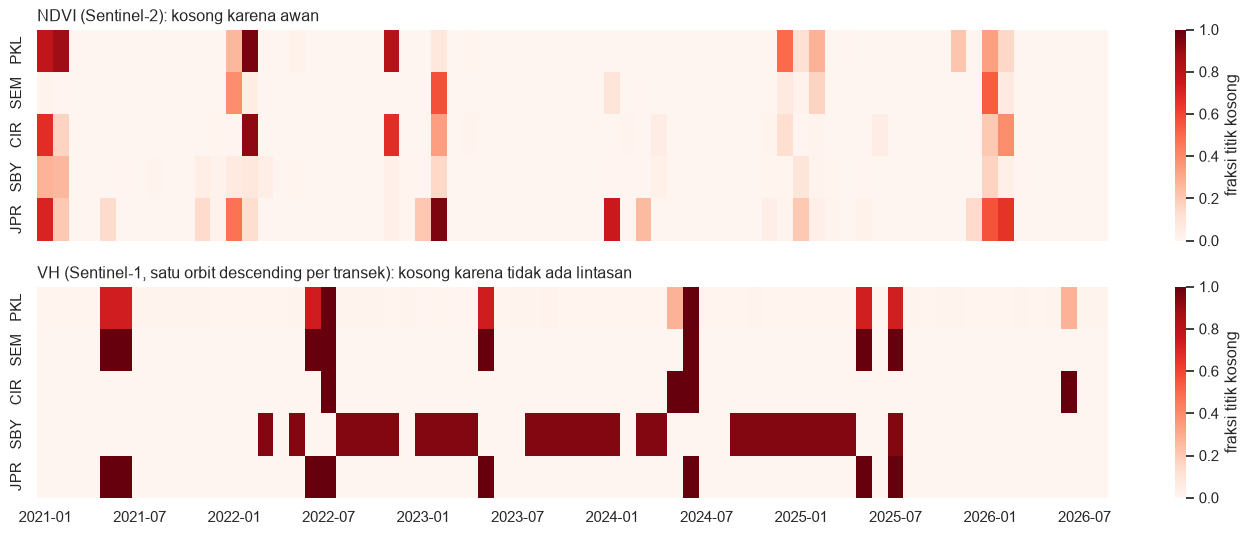

,NDVI kosong (rata2),bulan NDVI kosong >50%,VH kosong (rata2),bulan VH kosong >50%
PKL,0.080,4,0.112,8
SEM,0.030,2,0.118,8
CIR,0.054,3,0.059,4
SBY,0.021,0,0.376,27
JPR,0.084,5,0.118,8


In [4]:
miss_ndvi = pd.DataFrame({r: np.isnan(NDVI[REG_I == r]).mean(axis=(0, 1)) for r in REG}, index=BULAN.astype(str))
miss_vh = pd.DataFrame({r: np.isnan(VH[REG_I == r]).mean(axis=(0, 1)) for r in REG}, index=BULAN.astype(str))
fig, ax = plt.subplots(2, 1, figsize=(14, 5.5), sharex=True)
for a, m, jud in [(ax[0], miss_ndvi, "NDVI (Sentinel-2): kosong karena awan"),
                  (ax[1], miss_vh, "VH (Sentinel-1, satu orbit descending per transek): kosong karena tidak ada lintasan")]:
    sns.heatmap(m.T, ax=a, cmap="Reds", vmin=0, vmax=1, cbar_kws=dict(label="fraksi titik kosong"))
    a.set_title(jud, loc="left"); a.set_ylabel("")
ax[1].set_xticks(np.arange(0, T, 6) + 0.5); ax[1].set_xticklabels(BULAN.astype(str)[::6], rotation=0)
plt.tight_layout(); simpan("03_pola_kekosongan"); plt.show()
ring = pd.DataFrame({"NDVI kosong (rata2)": miss_ndvi.mean(), "bulan NDVI kosong >50%": (miss_ndvi > 0.5).sum(),
                     "VH kosong (rata2)": miss_vh.mean(), "bulan VH kosong >50%": (miss_vh > 0.5).sum()})
tabel(ring.round(3), "03_ringkasan_kekosongan")

### 3.2 Mengapa radar kosong? Orbit yang dipakai vs citra yang sebenarnya tersedia

`profil_s1` mengambil **satu orbit descending per transek** (supaya sudut pandang seragam). Daftar akuisisi
(`s1_akuisisi_<REG>.csv`) mencatat semua citra yang meliput koridor wilayah, dari orbit mana pun.

In [5]:
bl = pd.period_range(BULAN[0], BULAN[-1], freq="M")
rows = []
for r in REG:
    a = AK[AK.region_code == r]
    D, A = set(a[a["pass"] == "DESCENDING"].bulan), set(a[a["pass"] == "ASCENDING"].bulan)
    rows.append(dict(wilayah=r, orbit_profil_s1=", ".join(map(str, sorted(ORB[REG_I == r].orbit_desc.unique()))),
                     bulan_VH_kosong_profil_s1=int((miss_vh[r] > 0.5).sum()),
                     bulan_tanpa_descending=sum(m not in D for m in bl), bulan_tanpa_ascending=sum(m not in A for m in bl),
                     bulan_tanpa_citra_sama_sekali=sum((m not in D) and (m not in A) for m in bl)))
orb_tab = pd.DataFrame(rows).set_index("wilayah")
display(tabel(orb_tab, "03_orbit_vs_ketersediaan"))
if S1M is not None:
    vh_d, vh_a = S1M["VHD"], S1M["VHA"]
    kos = pd.DataFrame({r: dict(profil_s1=(np.isnan(VH[REG_I == r]).mean(axis=(0, 1)) > 0.5).sum(),
                                s1m_descending=(np.isnan(vh_d[REG_I == r]).mean(axis=(0, 1)) > 0.5).sum(),
                                s1m_ascending=(np.isnan(vh_a[REG_I == r]).mean(axis=(0, 1)) > 0.5).sum(),
                                s1m_gabungan=((np.isnan(vh_d[REG_I == r]) & np.isnan(vh_a[REG_I == r])).mean(axis=(0, 1)) > 0.5).sum())
                        for r in REG}).T
    display(tabel(kos, "03_kekosongan_s1m"))

,orbit_profil_s1,bulan_VH_kosong_profil_s1,bulan_tanpa_descending,bulan_tanpa_ascending,bulan_tanpa_citra_sama_sekali
wilayah,,,,,
PKL,"76, 149",8,2,13,1
SEM,76,8,8,9,3
CIR,149,4,4,13,1
SBY,"3, 105",27,0,4,0
JPR,76,8,8,11,3


,profil_s1,s1m_descending,s1m_ascending,s1m_gabungan
PKL,8,8,13,4
SEM,8,8,11,3
CIR,4,4,16,1
SBY,27,27,4,3
JPR,8,8,11,3


**Interpretasi.** Kedua sensor kosong dengan sebab yang berbeda:

- **NDVI (awan)** kosong **musiman**, puncaknya Desember–Februari. SBY hampir tidak pernah kosong. Kekosongan seperti ini
  acak terhadap posisi tepi, sehingga aman dilewati model state-space.
- **VH (radar)** di `profil_s1` kosong **terstruktur**: SBY kosong **27 dari 68 bulan**, wilayah lain 4–8 bulan. Penyebabnya
  **bukan ketiadaan citra**, tetapi `profil_s1` mengunci setiap transek ke satu orbit descending (SBY: orbit 3 dan 105).
- Paket **`profil_s1m`** (semua orbit, ascending dan descending terpisah) menutup celah itu. Bulan kosong gabungan tinggal
  **SBY 3, PKL 4, SEM 3, JPR 3, CIR 1**. Untuk SBY, perbaikannya datang dari lintasan **ascending** (4 bulan kosong); orbit
  descending lain ternyata tidak meliput titik transek SBY (tetap 27).

Notebook analisis memakai `profil_s1m`. Selisih sistematis ascending–descending dikoreksi per titik (median −0,17 dB).

## 4. Apakah sinyal satelit membedakan mangrove?

Tepi mangrove bulanan dideteksi dari NDVI (kanopi) dan VH (struktur kanopi). Sebaran keduanya dibandingkan pada titik
mangrove GMW 2022 dan kelas Dynamic World 2022 untuk titik non-mangrove.

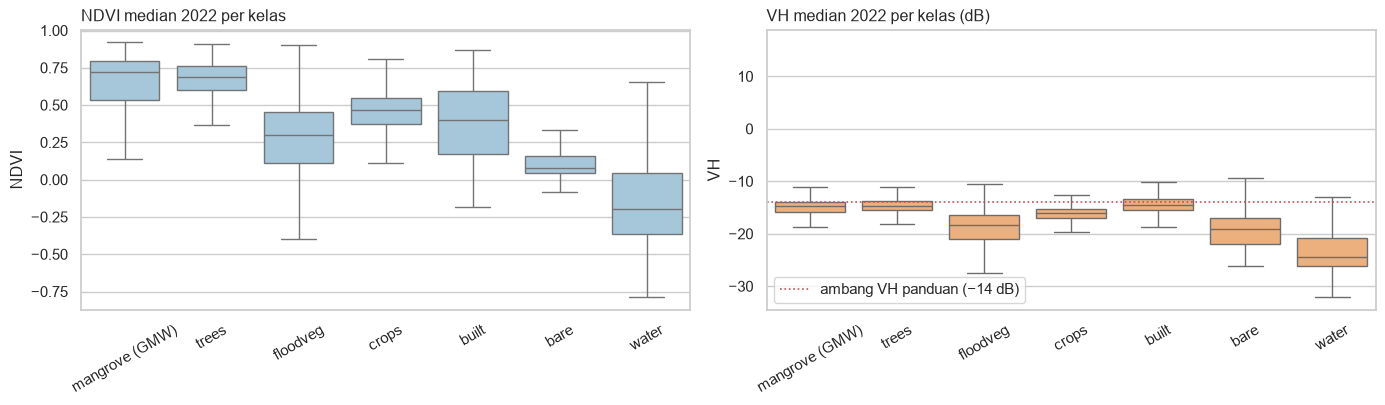

NDVI                 VH              
                             0.1   0.5   0.9    0.1    0.5    0.9
mangrove (GMW)              0.22  0.72  0.84 -17.81 -14.68 -13.31
trees                       0.51  0.69  0.81 -16.51 -14.61 -13.09
floodveg                   -0.06  0.30  0.59 -23.38 -18.40 -15.15
crops                       0.30  0.46  0.62 -17.92 -16.08 -14.53
built                       0.06  0.40  0.70 -16.50 -14.51 -11.66
bare                        0.01  0.08  0.27 -24.17 -19.17 -14.52
water                      -0.48 -0.20  0.26 -27.05 -24.38 -17.98
mangrove (WorldCover 2021)  0.12  0.64  0.82 -19.03 -15.11 -13.38

In [6]:
th22 = TH_T == 2022
ndvi22 = np.nanmedian(NDVI[:, :, th22], axis=2); vh22 = np.nanmedian(VH[:, :, th22], axis=2)
kelas = np.where(g(2022), "mangrove (GMW)", np.array(KELAS_DW)[DOM[:, :, 1]])
d = pd.DataFrame(dict(kelas=kelas.ravel(), NDVI=ndvi22.ravel(), VH=vh22.ravel())).dropna().sample(250_000, random_state=1)
urut = ["mangrove (GMW)", "trees", "floodveg", "crops", "built", "bare", "water"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(d, x="kelas", y="NDVI", order=urut, ax=ax[0], fliersize=0, color="#9ecae1")
sns.boxplot(d, x="kelas", y="VH", order=urut, ax=ax[1], fliersize=0, color="#fdae6b")
ax[1].axhline(-14, c="r", ls=":", lw=1.2, label="ambang VH panduan (−14 dB)")
for a in ax: a.tick_params(axis="x", rotation=30); a.set_xlabel("")
ax[1].legend(loc="lower left")
ax[0].set_title("NDVI median 2022 per kelas", loc="left"); ax[1].set_title("VH median 2022 per kelas (dB)", loc="left")
plt.tight_layout(); simpan("04_ndvi_vh_per_kelas"); plt.show()
q = d.groupby("kelas")[["NDVI", "VH"]].quantile([0.1, 0.5, 0.9]).unstack().loc[urut].round(2)
wcq = pd.DataFrame({"NDVI": np.nanquantile(ndvi22[WC == 95], [0.1, 0.5, 0.9]), "VH": np.nanquantile(vh22[WC == 95], [0.1, 0.5, 0.9])},
                   index=[0.1, 0.5, 0.9]).unstack().to_frame("mangrove (WorldCover 2021)").T.round(2)
tabel(pd.concat([q, wcq]), "04_kuantil_ndvi_vh")

**Interpretasi.** Mangrove (GMW 2022) punya median **NDVI 0,72 dan VH −14,7 dB**, hampir sama dengan pohon darat (0,69;
−14,6 dB). NDVI + VH memisahkan **vegetasi dari air dan lahan terbuka** dengan baik (air: NDVI −0,20, VH −24,4 dB), tetapi
**tidak memisahkan mangrove dari pohon darat**. Ada dua akibat:

1. **Keberadaan** mangrove tidak bisa ditentukan dari sinyal saja, dan harus diambil dari peta mangrove (GMW,
   WorldCover). Sinyal Sentinel dipakai untuk **posisi tepi bulanan** dan untuk **mengonfirmasi** peta tersebut.
2. Ambang VH panduan (−14 dB) berada **di atas** median VH mangrove, sehingga lebih dari separuh piksel mangrove akan gagal
   lolos. Ambang perlu dikalibrasi.

Titik mangrove WorldCover punya NDVI lebih rendah (median 0,64, persentil-10 hanya 0,12) daripada mangrove GMW. Artinya,
WorldCover memasukkan sebagian piksel air/lumpur di tepi tegakan. Ini diuji langsung di Bagian 5.

## 5. Mangrove: tiga sumber dan perubahannya

Tiga sumber keberadaan mangrove tersedia: **ESA WorldCover 2021** (10 m, satu tahun), **GMW v4.1.12** (30 m,
tahunan 1985–2025), dan **sinyal Sentinel-1/2** (10 m, bulanan 2021–2026). Transek dianggap bermangrove bila ada
rangkaian ≥ 30 m (3 titik) dalam 0–1.500 m.

### 5.1 WorldCover 2021 vs GMW 2021

In [7]:
wc_t, g21_t, g25_t = ada_rangkaian(WC == 95), ada_rangkaian(g(2021)), ada_rangkaian(g(2025))
GRUP = np.select([wc_t & g21_t, ~wc_t & g21_t, wc_t & ~g21_t], ["A: keduanya", "B: hanya GMW", "C: hanya WorldCover"], "D: tidak ada")
display(pd.crosstab(pd.Series(wc_t, name="WorldCover 2021"), pd.Series(g21_t, name="GMW 2021"), margins=True))
tabel(pd.crosstab(pd.Series(REG_I, name="wilayah"), pd.Series(GRUP, name="grup")).reindex(REG), "05_kesepakatan_wc_gmw")

GMW 2021,False,True,All
WorldCover 2021,,,
False,1306,357,1663
True,54,648,702
All,1360,1005,2365


grup,A: keduanya,B: hanya GMW,C: hanya WorldCover,D: tidak ada
wilayah,,,,
PKL,5,47,12,226
SEM,86,72,19,138
CIR,35,117,5,248
SBY,519,116,18,512
JPR,3,5,0,182


### 5.2 Siapa yang benar? Sinyal Sentinel sebagai penentu ketiga

Pada titik yang diklaim mangrove oleh tiap grup, dihitung sinyal Sentinel 2021 dan proporsi titik yang **lolos
kriteria vegetasi mangrove** (NDVI median > 0,4, VH median > −16 dB, kelas Dynamic World pohon/vegetasi tergenang
dengan P(terbangun) < 0,3, dan NDVI persentil-20 > 0,3 atau hijau sepanjang tahun). Kriteria ini hanya alat
pembanding di sini; kalibrasinya dilakukan di notebook analisis.

In [8]:
m21 = TH_T == 2021
ndvi_med = np.nanmedian(NDVI[:, :, m21], 2); ndvi_p20 = np.nanquantile(NDVI[:, :, m21], 0.2, axis=2)
vh_med = np.nanmedian(VH[:, :, m21], 2); dw21 = np.array(KELAS_DW)[DOM[:, :, 0]]
LOLOS21 = (ndvi_med > 0.4) & (vh_med > -16) & np.isin(dw21, ["trees", "floodveg"]) & (DW[:, :, 0, 3] < 0.3) & (ndvi_p20 > 0.3)
zona = np.zeros((1, P), bool); zona[:, :JMAX] = True
rows = []
for G, src in [("A: keduanya", g(2021) & (WC == 95)), ("B: hanya GMW", g(2021)), ("C: hanya WorldCover", WC == 95)]:
    M = (GRUP == G)[:, None] & src & zona
    dd = pd.Series(dw21[M]).value_counts(normalize=True)
    rows.append({"grup": G, "transek": int((GRUP == G).sum()), "titik": int(M.sum()),
                 "NDVI median": np.nanmedian(ndvi_med[M]), "NDVI p20": np.nanmedian(ndvi_p20[M]), "VH median (dB)": np.nanmedian(vh_med[M]),
                 "lolos kriteria": np.nanmean(LOLOS21[M]), **{f"DW {k}": dd.get(k, 0) for k in ["trees", "floodveg", "water", "crops", "built", "bare"]}})
adj = pd.DataFrame(rows).set_index("grup")
display(tabel(adj.round(2).T, "05_adjudikasi_sentinel"))
fr = pd.DataFrame({"wilayah": REG_I, "grup": GRUP,
                   "fraksi_lolos": [np.nanmean(LOLOS21[i, :JMAX][g(2021)[i, :JMAX]]) if g21_t[i] else np.nan for i in range(N)]})
tabel(fr[fr.grup == "B: hanya GMW"].groupby("wilayah").fraksi_lolos.agg(
    transek="size", median_fraksi_lolos="median", proporsi_transek_lolos_50=lambda s: (s >= 0.5).mean()).reindex(REG).round(2),
      "05_adjudikasi_B_per_wilayah")

grup,A: keduanya,B: hanya GMW,C: hanya WorldCover
transek,648.00,357.00,54.00
titik,15561.00,4819.00,733.00
NDVI median,0.73,0.68,0.33
NDVI p20,0.63,0.57,0.24
VH median (dB),-14.34,-14.78,-16.61
lolos kriteria,0.82,0.64,0.21
DW trees,0.53,0.42,0.09
DW floodveg,0.37,0.33,0.33
DW water,0.09,0.25,0.57
DW crops,0.00,0.00,0.01


,transek,median_fraksi_lolos,proporsi_transek_lolos_50
wilayah,,,
PKL,47,0.33,0.34
SEM,72,0.59,0.65
CIR,117,0.56,0.57
SBY,116,0.65,0.65
JPR,5,0.88,0.80


**Interpretasi: GMW lebih bisa dipercaya daripada WorldCover untuk keberadaan mangrove, kecuali di Pekalongan.**

- Kedua peta sepakat pada **648 transek**. **357 transek** bermangrove menurut GMW saja, dan **54** menurut WorldCover
  saja.
- Di transek **"hanya GMW"**, sinyal Sentinel hampir sama dengan transek yang disepakati: NDVI 0,68 vs 0,73, VH −14,8 vs
  −14,3 dB, dan **64% titik lolos kriteria** vegetasi mangrove (vs 82%). WorldCover **melewatkan** tegakan-tegakan ini.
- Di transek **"hanya WorldCover"**, sinyalnya lemah: NDVI 0,33, hanya 21% titik lolos, dan **57% titik berkelas air**.
  Ini kemungkinan tegakan sangat jarang atau salah klasifikasi.
- Pengecualian **Pekalongan**: hanya 34% transek "hanya GMW" di PKL yang titiknya mayoritas lolos (SBY 65%, SEM 65%,
  CIR 57%). GMW di PKL perlu dikonfirmasi per transek.

Konsekuensinya, domain transek bermangrove sebaiknya diambil dari **GMW ∪ WorldCover dengan syarat konfirmasi sinyal
Sentinel**, bukan dari WorldCover 2021 saja.

### 5.3 Tren mangrove GMW 1985–2025

GMW v4.1.12 memberi sebaran tahunan. Menurut README GMW, tahun sebelum 1999/2000 sebagian diisi dari tahun lain,
sehingga periode itu diberi arsir dan tidak dipakai untuk laju.

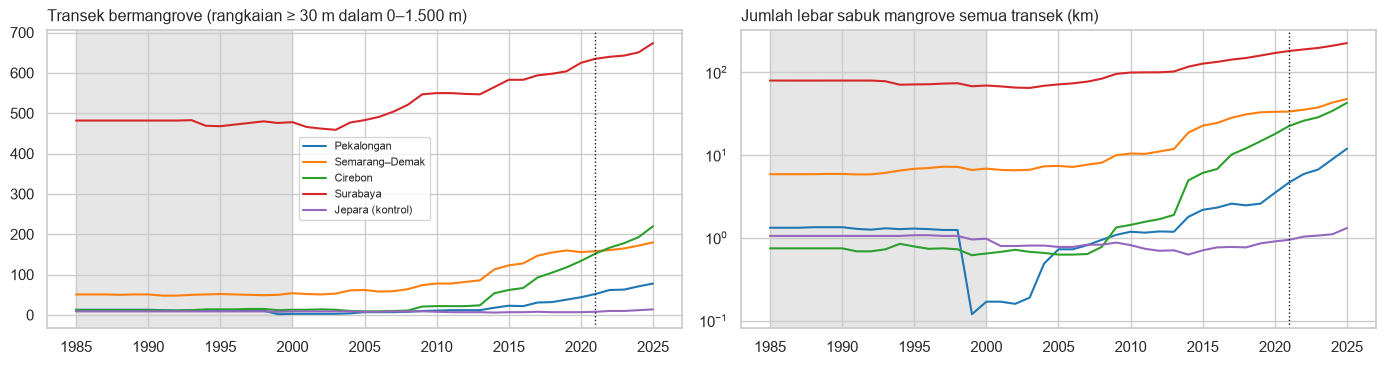

transek_bermangrove                           lebar_total_km                        
                     CIR   JPR   PKL    SBY    SEM            CIR  JPR   PKL    SBY   SEM
2000                13.0   9.0   3.0  478.0   54.0            0.6  1.0   0.2   69.6   6.9
2005                 9.0   8.0   7.0  483.0   62.0            0.6  0.8   0.7   71.8   7.4
2010                22.0   8.0  11.0  550.0   78.0            1.4  0.8   1.2   99.9  10.5
2015                62.0   7.0  23.0  583.0  123.0            6.1  0.7   2.2  127.9  22.8
2020               134.0   7.0  44.0  625.0  156.0           18.0  0.9   3.5  172.0  33.5
2021               152.0   8.0  52.0  635.0  158.0           22.6  1.0   4.7  182.0  33.7
2023               178.0  10.0  63.0  643.0  165.0           28.8  1.1   6.7  198.0  37.8
2025               220.0  14.0  78.0  674.0  180.0           43.0  1.3  12.0  226.6  47.9

In [9]:
lebar = GMW[:, :JMAX, :].sum(1) * STEP                                   # lebar sabuk mangrove per transek (m) [transek, tahun]
ada_th = np.stack([ada_rangkaian(GMW[:, :, k]) for k in range(len(TAHUN_GMW))], 1)
tren = pd.concat({"transek_bermangrove": pd.DataFrame(ada_th, columns=TAHUN_GMW).groupby(REG_I).sum(),
                  "lebar_total_km": pd.DataFrame(lebar, columns=TAHUN_GMW).groupby(REG_I).sum() / 1000}).T
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
for r in REG:
    ax[0].plot(TAHUN_GMW, tren[("transek_bermangrove", r)], c=REG_WARNA[r], label=REG_NAMA[r])
    ax[1].plot(TAHUN_GMW, tren[("lebar_total_km", r)], c=REG_WARNA[r])
for a in ax:
    a.axvspan(1985, 2000, color="0.9", zorder=0); a.axvline(2021, c="k", ls=":", lw=1)
ax[0].set_title("Transek bermangrove (rangkaian ≥ 30 m dalam 0–1.500 m)", loc="left"); ax[0].legend(fontsize=8)
ax[1].set_title("Jumlah lebar sabuk mangrove semua transek (km)", loc="left"); ax[1].set_yscale("log")
plt.tight_layout(); simpan("05_tren_gmw"); plt.show()
tabel(tren.loc[[2000, 2005, 2010, 2015, 2020, 2021, 2023, 2025]].round(1), "05_tren_gmw")

### 5.4 Perubahan 2021 → 2025: nyata atau artefak?

Bila titik yang **baru** menjadi mangrove di GMW memang tumbuh, sinyal Sentinel (yang dibuat terpisah dari GMW) harus
berubah bertahap dari air/lumpur menjadi kanopi. Sebaliknya untuk titik yang **hilang**.

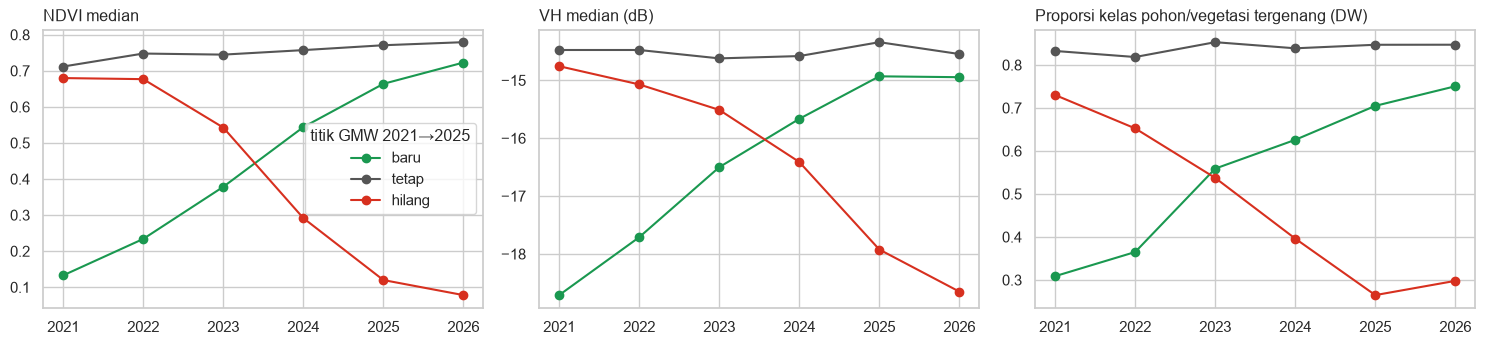

NDVI                  VH               kanopi_DW              air_DW             
grup   baru hilang tetap   baru hilang  tetap      baru hilang tetap   baru hilang tetap
tahun                                                                                   
2021   0.13   0.68  0.71 -18.71 -14.76 -14.48      0.31   0.73  0.83   0.68   0.27  0.17
2022   0.23   0.68  0.75 -17.71 -15.07 -14.48      0.37   0.65  0.82   0.63   0.35  0.18
2023   0.38   0.54  0.74 -16.50 -15.51 -14.62      0.56   0.54  0.85   0.43   0.46  0.14
2024   0.54   0.29  0.76 -15.66 -16.41 -14.58      0.63   0.40  0.84   0.36   0.57  0.16
2025   0.66   0.12  0.77 -14.93 -17.92 -14.34      0.70   0.26  0.85   0.29   0.67  0.15
2026   0.72   0.08  0.78 -14.94 -18.65 -14.54      0.75   0.30  0.85   0.24   0.63  0.15

,titik,proporsi,transek
di depan sabuk (arah laut),2482.0,0.24,316.0
mengisi celah di dalam sabuk,3571.0,0.34,373.0
di belakang sabuk (arah darat/tambak),3123.0,0.30,375.0
transek tanpa mangrove 2021,1347.0,0.13,165.0


Titik baru 10,523 vs hilang 1,842 (0–1.500 m). Titik hilang menjadi (DW 2025): {'water': 0.67, 'floodveg': 0.21, 'trees': 0.06, 'built': 0.04, 'bare': 0.03}


,titik_baru,NDVI_baru_2021,NDVI_baru_2025,baru_NDVI_naik_0_2,VH_baru_naik_dB,titik_hilang,NDVI_hilang_2021,NDVI_hilang_2025
PKL,790.0,0.31,0.51,0.32,0.65,60.0,0.64,-0.11
SEM,2013.0,0.19,0.57,0.61,1.54,599.0,0.70,-0.05
CIR,2247.0,0.07,0.69,0.71,3.65,213.0,0.67,0.13
SBY,5436.0,0.13,0.70,0.72,3.49,970.0,0.67,0.22
JPR,37.0,0.47,0.58,0.14,0.43,0.0,NaN,NaN


In [10]:
zona_m = np.zeros((N, P), bool); zona_m[:, :JMAX] = True
BARU = g(2025) & ~g(2021) & zona_m; TETAP = g(2025) & g(2021) & zona_m; HILANG = g(2021) & ~g(2025) & zona_m
lintas = []
for y in TAHUN:
    my = TH_T == y
    nd = np.nanmedian(NDVI[:, :, my], 2); vh = np.nanmedian(VH[:, :, my], 2); dk = np.array(KELAS_DW)[DOM[:, :, y - 2021]]
    for nama, M in [("baru", BARU), ("tetap", TETAP), ("hilang", HILANG)]:
        lintas.append(dict(tahun=y, grup=nama, NDVI=np.nanmedian(nd[M]), VH=np.nanmedian(vh[M]),
                           kanopi_DW=np.isin(dk[M], ["trees", "floodveg"]).mean(), air_DW=(dk[M] == "water").mean()))
lintas = pd.DataFrame(lintas)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for nama, c in [("baru", "#1a9850"), ("tetap", "#555555"), ("hilang", "#d7301f")]:
    s = lintas[lintas.grup == nama]
    ax[0].plot(s.tahun, s.NDVI, "o-", c=c, label=nama); ax[1].plot(s.tahun, s.VH, "o-", c=c); ax[2].plot(s.tahun, s.kanopi_DW, "o-", c=c)
ax[0].set_title("NDVI median", loc="left"); ax[1].set_title("VH median (dB)", loc="left"); ax[2].set_title("Proporsi kelas pohon/vegetasi tergenang (DW)", loc="left")
ax[0].legend(title="titik GMW 2021→2025"); [a.set_xlabel("") for a in ax]
plt.tight_layout(); simpan("05_lintasan_perubahan"); plt.show()
display(tabel(lintas.pivot(index="tahun", columns="grup").round(2), "05_lintasan_perubahan"))

has21 = g(2021)[:, :JMAX].any(1)
first21 = np.where(has21, g(2021)[:, :JMAX].argmax(1), -1)
last21 = np.where(has21, JMAX - 1 - g(2021)[:, :JMAX][:, ::-1].argmax(1), -1)
j = np.arange(P)[None, :]
letak = {"di depan sabuk (arah laut)": BARU & has21[:, None] & (j < first21[:, None]),
         "mengisi celah di dalam sabuk": BARU & has21[:, None] & (j >= first21[:, None]) & (j <= last21[:, None]),
         "di belakang sabuk (arah darat/tambak)": BARU & has21[:, None] & (j > last21[:, None]),
         "transek tanpa mangrove 2021": BARU & ~has21[:, None]}
lt = pd.DataFrame({k: dict(titik=int(M.sum()), proporsi=M.sum() / BARU.sum(), transek=int(M.any(1).sum())) for k, M in letak.items()}).T
display(tabel(lt.round(2), "05_letak_mangrove_baru"))
d25 = np.array(KELAS_DW)[DOM[:, :, 4]]
print(f"Titik baru {BARU.sum():,} vs hilang {HILANG.sum():,} (0–1.500 m). Titik hilang menjadi (DW 2025): "
      f"{pd.Series(d25[HILANG]).value_counts(normalize=True).round(2).to_dict()}")
# konfirmasi per wilayah: apakah titik baru benar-benar menghijau dan titik hilang benar-benar meranggas?
nd21 = np.nanmedian(NDVI[:, :, TH_T == 2021], 2); nd25 = np.nanmedian(NDVI[:, :, TH_T == 2025], 2)
vh21 = np.nanmedian(VH[:, :, TH_T == 2021], 2); vh25 = np.nanmedian(VH[:, :, TH_T == 2025], 2)
rw = {}
for r in REG:
    mb, mh = BARU & (REG_I == r)[:, None], HILANG & (REG_I == r)[:, None]
    rw[r] = dict(titik_baru=int(mb.sum()), NDVI_baru_2021=np.nanmedian(nd21[mb]), NDVI_baru_2025=np.nanmedian(nd25[mb]),
                 baru_NDVI_naik_0_2=np.nanmean((nd25 - nd21)[mb] > 0.2), VH_baru_naik_dB=np.nanmedian((vh25 - vh21)[mb]),
                 titik_hilang=int(mh.sum()), NDVI_hilang_2021=np.nanmedian(nd21[mh]) if mh.any() else np.nan,
                 NDVI_hilang_2025=np.nanmedian(nd25[mh]) if mh.any() else np.nan)
tabel(pd.DataFrame(rw).T.round(2), "05_konfirmasi_perubahan_per_wilayah")

### 5.5 Tepi laut mangrove menurut GMW, 2021 → 2025 (deskriptif)

In [11]:
has25 = g(2025)[:, :JMAX].any(1); both = has21 & has25
dY = (g(2025)[:, :JMAX].argmax(1) - first21)[both] * STEP             # + = tepi laut mundur ke darat
tp = pd.DataFrame({"wilayah": REG_I[both], "dY": dY})
tepi = tp.groupby("wilayah").dY.agg(transek="size", median_m="median", maju_30m=lambda s: (s <= -30).mean(),
                                    mundur_30m=lambda s: (s >= 30).mean(), tetap=lambda s: (s.abs() < 30).mean()).reindex(REG)
tabel(tepi.round(2), "05_tepi_laut_gmw_2021_2025")

,transek,median_m,maju_30m,mundur_30m,tetap
wilayah,,,,,
PKL,56,0.0,0.34,0.07,0.59
SEM,165,0.0,0.18,0.27,0.55
CIR,159,0.0,0.36,0.16,0.48
SBY,640,0.0,0.28,0.08,0.63
JPR,12,0.0,0.33,0.00,0.67


**Interpretasi: secara keseluruhan mangrove Pantura bertambah, tetapi ada kehilangan nyata yang terkumpul di SBY dan SEM.**

1. **Tren GMW.** Transek bermangrove naik dari 2000 ke 2025 di semua wilayah: CIR 13 → 220, PKL 3 → 78, SEM 54 → 180,
   SBY 478 → 674. Kenaikan paling cepat terjadi setelah 2015.
2. **Perubahan 2021 → 2025 itu nyata.** Ada 10.523 titik baru dan 1.842 titik hilang (0–1,5 km). Pada titik baru, sinyal
   Sentinel yang dibuat terpisah dari GMW berubah **bertahap** dari tahun ke tahun: NDVI 0,13 → 0,66, VH −18,7 → −14,9 dB,
   kelas kanopi 31% → 70%. Pada titik hilang, arahnya kebalikan: NDVI 0,68 → 0,12, dan **67% menjadi air**, yaitu
   tenggelam, abrasi, atau dijadikan tambak.
3. **Kekuatan konfirmasi berbeda per wilayah.** CIR dan SBY kuat (71–72% titik baru NDVI-nya naik > 0,2; VH +3,5 dB), SEM
   sedang (61%; +1,5 dB), **PKL lemah (32%; +0,65 dB)**. Pertumbuhan GMW di PKL sebagian kemungkinan artefak.
4. **Letak pertumbuhan.** 34% mengisi celah di dalam sabuk, **30% di belakang sabuk (ke arah tambak)**, 24% di depan sabuk
   (akresi ke laut), dan 13% di transek yang belum bermangrove pada 2021.
5. **Tepi laut.** Median perubahan 0 m di semua wilayah (GMW 30 m tidak melihat pergeseran < 30 m). **SEM satu-satunya
   wilayah yang tepinya lebih sering mundur (27%) daripada maju (18%)**. SEM juga wilayah dengan amblesan tertinggi
   (Bagian 6).

Konsekuensinya, domain satu tahun (2021) tidak memadai. Analisis perlu **domain dan batas pencarian dinamis**, dan kelas
dinamika (stabil, ekspansi, hilang) menjadi informasi tersendiri untuk dashboard.

## 6. Data tekanan: amblesan, kovariat transek, penghalang

### 6.1 Amblesan InSAR: sebaran, sumber nilai, dan validasi GNSS

Nilai `subs_cm_th` per transek diisi berjenjang oleh langkah akuisisi 8: **pantai** (median titik InSAR 0–1 km di belakang
garis pantai), **darat** (median seluruh bagian darat transek, dipakai bila zona pantai berkoherensi rendah), atau
**tetangga** (median transek lain dalam 1 km). Tiap jenjang punya galat berbeda; besarnya diperkirakan di bawah.

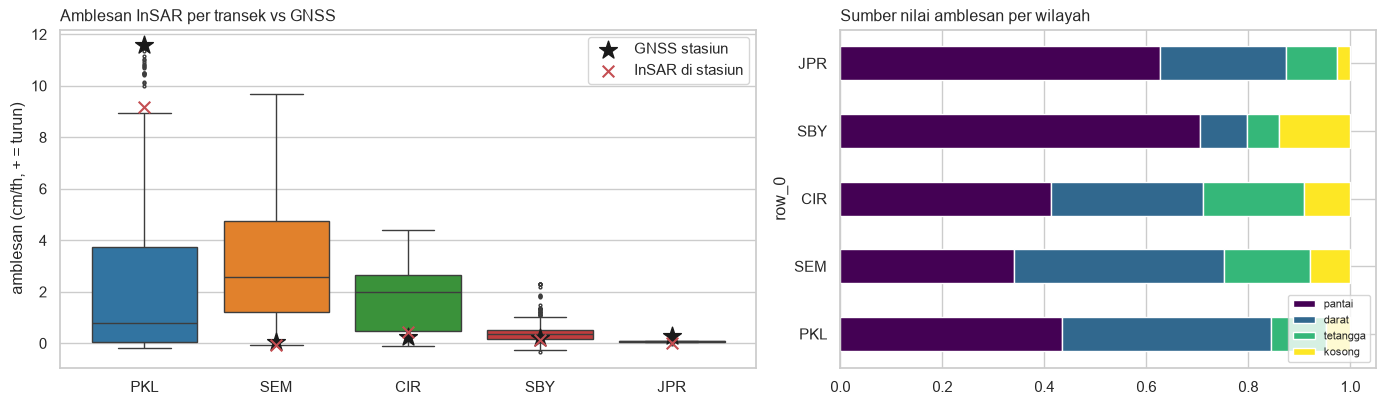

Pantai: selisih InSAR − GNSS per stasiun (cm/th): {'PKL': 2.43, 'SEM': 0.14, 'CIR': -0.21, 'SBY': 0.08, 'JPR': 0.24}


n  median_abs  sd_robust  galat_relatif_median
darat sebagai pengganti pantai  semua                1485.0       0.030      0.044                 0.097
                                amblesan < 1 cm/th   1216.0       0.020      0.030                 0.100
                                amblesan >= 1 cm/th   269.0       0.190      0.282                 0.057
tetangga (leave-one-out ≤ 1 km) semua                1855.0       0.035      0.052                 0.082
                                amblesan < 1 cm/th   1362.0       0.020      0.030                 0.100
                                amblesan >= 1 cm/th   493.0       0.175      0.259                 0.050

In [12]:
SUBS = -TR.subs_cm_th                                   # + = tanah turun (cm/th)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw=dict(width_ratios=[1.3, 1]))
sns.boxplot(x=REG_I, y=SUBS.to_numpy(), order=REG, ax=ax[0], palette=REG_WARNA, fliersize=2)
gg = GN.set_index("region_code").loc[REG]
ax[0].scatter(range(5), -gg.laju_cm_th, marker="*", s=180, c="k", zorder=5, label="GNSS stasiun")
ax[0].scatter(range(5), -gg.vlm_insar_stasiun_cm_th, marker="x", s=70, c="r", zorder=5, label="InSAR di stasiun")
ax[0].set_ylabel("amblesan (cm/th, + = turun)"); ax[0].legend(); ax[0].set_title("Amblesan InSAR per transek vs GNSS", loc="left")
sumber = pd.crosstab(REG_I, TR.subs_sumber.fillna("kosong"), normalize="index").reindex(REG)[["pantai", "darat", "tetangga", "kosong"]]
sumber.plot.barh(stacked=True, ax=ax[1], colormap="viridis"); ax[1].set_title("Sumber nilai amblesan per wilayah", loc="left")
ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); simpan("06_amblesan"); plt.show()

# galat per jenjang sumber
val_gnss = (gg.vlm_insar_stasiun_cm_th - gg.laju_cm_th)
both_pd = TR.subs_pantai_cm_th.notna() & TR.subs_darat_cm_th.notna()
d_pd = (TR.subs_darat_cm_th - TR.subs_pantai_cm_th)[both_pd]
cxy = TR[["cx", "cy"]].to_numpy(); asli = TR.subs_sumber.isin(["pantai", "darat"]).to_numpy(); v = TR.subs_cm_th.to_numpy()
loo, loo_ref = [], []
for k in np.flatnonzero(asli):
    dd = np.hypot(*(cxy[asli] - cxy[k]).T); nb_ = (dd > 0) & (dd <= 1000)
    if nb_.sum() >= 1:
        loo.append(np.median(v[asli][nb_]) - v[k]); loo_ref.append(v[k])
loo, loo_ref = np.array(loo), np.array(loo_ref)
def ringkas_galat(e, ref):
    e, ref = np.asarray(e), np.abs(np.asarray(ref))
    out = {}
    for nama, m in [("semua", np.ones(len(e), bool)), ("amblesan < 1 cm/th", ref < 1), ("amblesan >= 1 cm/th", ref >= 1)]:
        out[nama] = dict(n=int(m.sum()), median_abs=np.median(np.abs(e[m])), sd_robust=1.4826 * np.median(np.abs(e[m] - np.median(e[m]))),
                         galat_relatif_median=np.median(np.abs(e[m]) / np.maximum(ref[m], 0.1)))
    return out
galat = pd.concat({
    "darat sebagai pengganti pantai": pd.DataFrame(ringkas_galat(d_pd.to_numpy(), TR.subs_pantai_cm_th[both_pd].to_numpy())).T,
    "tetangga (leave-one-out ≤ 1 km)": pd.DataFrame(ringkas_galat(loo, loo_ref)).T})
print("Pantai: selisih InSAR − GNSS per stasiun (cm/th):", val_gnss.round(2).to_dict())
tabel(galat.round(3), "06_galat_amblesan_per_sumber")

### 6.2 Hubungan antar-kovariat transek

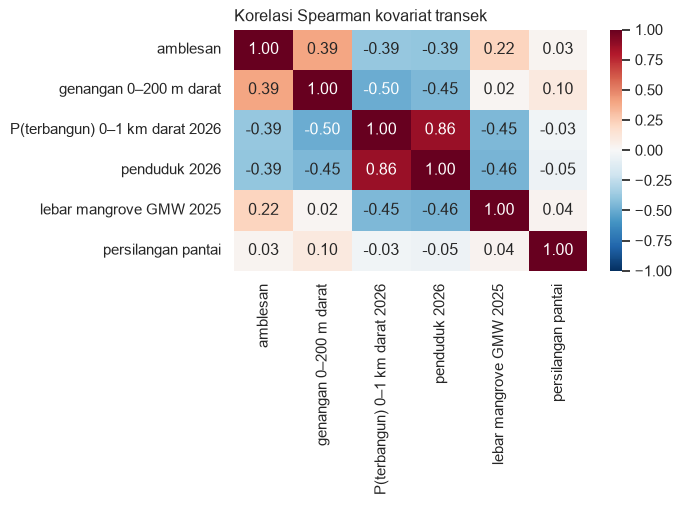

,amblesan,genangan 0–200 m darat,P(terbangun) 0–1 km darat 2026,penduduk 2026,lebar mangrove GMW 2025,persilangan pantai
amblesan,1.00,0.39,-0.39,-0.39,0.22,0.03
genangan 0–200 m darat,0.39,1.00,-0.50,-0.45,0.02,0.10
P(terbangun) 0–1 km darat 2026,-0.39,-0.50,1.00,0.86,-0.45,-0.03
penduduk 2026,-0.39,-0.45,0.86,1.00,-0.46,-0.05
lebar mangrove GMW 2025,0.22,0.02,-0.45,-0.46,1.00,0.04
persilangan pantai,0.03,0.10,-0.03,-0.05,0.04,1.00


,amblesan,genangan 0–200 m darat,P(terbangun) 0–1 km darat 2026,penduduk 2026,lebar mangrove GMW 2025,persilangan pantai
wilayah,,,,,,
PKL,0.77,0.04,0.06,480.0,0.0,1.0
SEM,2.58,0.15,0.04,56.9,70.0,1.0
CIR,2.00,0.15,0.04,25.8,30.0,1.0
SBY,0.37,0.00,0.15,1110.7,60.0,1.0
JPR,0.08,0.01,0.08,466.5,0.0,1.0


In [13]:
KOV = pd.DataFrame({
    "amblesan": SUBS.to_numpy(),
    "genangan 0–200 m darat": INUND[:, 50:71].mean(1),
    "P(terbangun) 0–1 km darat 2026": DW[:, 50:151, 5, 3].mean(1),
    "penduduk 2026": TR.pop_2026.to_numpy(),
    "lebar mangrove GMW 2025": lebar[:, -1],
    "persilangan pantai": TR.n_silang_pantai.to_numpy()}, index=IDS)
fig, ax = plt.subplots(figsize=(7, 5.2))
sns.heatmap(KOV.corr("spearman"), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Korelasi Spearman kovariat transek", loc="left"); plt.tight_layout(); simpan("06_korelasi_kovariat"); plt.show()
display(tabel(KOV.corr("spearman").round(2), "06_korelasi_kovariat"))
tabel(KOV.assign(wilayah=REG_I).groupby("wilayah").median().reindex(REG).round(2), "06_kovariat_median_wilayah")

### 6.3 Penghalang: persilangan OSM dan kedipan kelas "terbangun" Dynamic World

Kelas Dynamic World tahunan bisa **berkedip** (terbangun di satu tahun, tidak di tahun berikutnya, lalu terbangun lagi),
terutama pada pematang, jalan tanah, dan tambak kering. Kedipan membuat "bangunan baru" terlihat lebih banyak dari
sebenarnya.

In [14]:
jenis = BAR.assign(wilayah=BAR.transek_id.str[4:7]).pivot_table(index="jenis", columns="wilayah", values="transek_id", aggfunc="count", fill_value=0)
display(tabel(jenis.reindex(columns=REG, fill_value=0).loc[lambda x: x.sum(axis=1).sort_values(ascending=False).index], "06_jenis_penghalang"))
built = DOM == 3                                                         # [transek, titik, tahun]
kedip = (built[..., :-2] & ~built[..., 1:-1] & built[..., 2:]).any(-1)
pernah = built.any(-1)
baru_kasar = ~built[..., 0] & built[..., -1]
baru_tetap = ~built[..., 0] & ~built[..., 1] & built[..., 4] & built[..., 5]
darat = (DIST >= LEN_SEA)[None, :]
print(f"Titik darat yang pernah terbangun: {(pernah & darat).sum():,}; berkedip (terbangun-tidak-terbangun): "
      f"{(kedip & darat).sum():,} ({(kedip & darat).sum() / (pernah & darat).sum():.0%})")
print(f"'Terbangun baru' 2021→2026 kasar (tidak 2021, ya 2026): {(baru_kasar & darat).sum():,} titik; "
      f"dengan syarat tetap (tidak 2021–2022, ya 2025–2026): {(baru_tetap & darat).sum():,} titik di {(baru_tetap & darat).any(1).sum()} transek")
asal = pd.Series(np.array(KELAS_DW)[DOM[:, :, 0]][baru_tetap & darat]).value_counts(normalize=True).round(2)
tabel(pd.DataFrame({"titik": pd.Series(np.nonzero(baru_tetap & darat)[0]).map(dict(enumerate(REG_I))).value_counts()}).reindex(REG)
      .assign(asal_2021=[pd.Series(np.array(KELAS_DW)[DOM[REG_I == r, :, 0]][(baru_tetap & darat)[REG_I == r]]).value_counts(normalize=True).round(2).to_dict() for r in REG]),
      "06_terbangun_baru")

wilayah,PKL,SEM,CIR,SBY,JPR
jenis,,,,,
highway=trunk,108,159,239,568,10
railway=rail,205,73,245,104,0
dw_built_baru,38,106,64,183,23
highway=primary,12,26,9,118,84
highway=motorway,75,8,0,62,0
man_made=embankment,0,100,0,0,0
barrier=wall,0,0,50,3,0
highway=construction:motorway,0,46,0,0,0
man_made=breakwater,1,1,4,2,0


Titik darat yang pernah terbangun: 208,193; berkedip (terbangun-tidak-terbangun): 12,634 (6%)
'Terbangun baru' 2021→2026 kasar (tidak 2021, ya 2026): 15,521 titik; dengan syarat tetap (tidak 2021–2022, ya 2025–2026): 7,549 titik di 954 transek


,titik,asal_2021
PKL,765,"{'crops': 0.47, 'trees': 0.3, 'water': 0.14, '..."
SEM,1714,"{'water': 0.6, 'floodveg': 0.14, 'trees': 0.12..."
CIR,1035,"{'crops': 0.62, 'water': 0.19, 'trees': 0.13, ..."
SBY,3412,"{'trees': 0.39, 'water': 0.19, 'crops': 0.18, ..."
JPR,623,"{'trees': 0.64, 'crops': 0.29, 'water': 0.05, ..."


**Interpretasi.**

- **Amblesan berbeda tajam antarwilayah**: median SEM 2,6, CIR 2,0, PKL 0,8 (dengan ekor ekstrem), SBY 0,4, JPR 0,1 cm/th.
  InSAR cocok dengan GNSS di 4 stasiun (selisih ≤ 0,24 cm/th). **Di PKL, InSAR 2,4 cm/th lebih kecil daripada GNSS**
  (−9,2 vs −11,6), jadi amblesan ekstrem cenderung **diremehkan**.
- **Galat per sumber nilai.** Nilai pengganti (titik darat atau tetangga ≤ 1 km) berbeda sekitar **0,18–0,19 cm/th
  (5–6%)** dari nilai pantai pada transek yang amblesannya ≥ 1 cm/th, dan sekitar 0,02 cm/th pada transek yang hampir
  tidak ambles. Galat ini kecil dibanding perbedaan antarwilayah, tetapi cukup untuk mengecilkan koefisien regresi.
  Besarnya dipakai di uji galat ukur notebook analisis.
- **Kolinearitas.** Kawasan terbangun dan penduduk berkorelasi sangat kuat (ρ = 0,86), jadi keduanya tidak boleh masuk
  model yang sama. Amblesan berkorelasi sedang dengan genangan (ρ = 0,39) dan negatif dengan terbangun (ρ = −0,39):
  **kawasan paling ambles adalah kawasan tambak, bukan kota**.
- **Penghalang.** Persilangan didominasi jalan arteri dan rel. SEM punya 100 persilangan tanggul dan **46 ruas tol dalam
  konstruksi** (tol tanggul laut Semarang–Demak).
- **Kedipan Dynamic World.** 6% titik yang pernah terbangun berkedip. Hitungan "bangunan baru" 2021→2026 turun dari
  15.521 titik (kasar) menjadi **7.549 titik di 954 transek** bila disyaratkan tetap dua tahun. Hitungan kasar menggandakan
  konversi. Asal lahan yang menjadi bangunan: **di SEM 60% dari air/tambak**, di CIR 62% dari sawah, di SBY 39% dari
  pepohonan.

## 7. Lahan di belakang garis pantai: tambak dan perubahannya

### 7.1 Komposisi tutupan lahan darat (Dynamic World) 2021 vs 2026

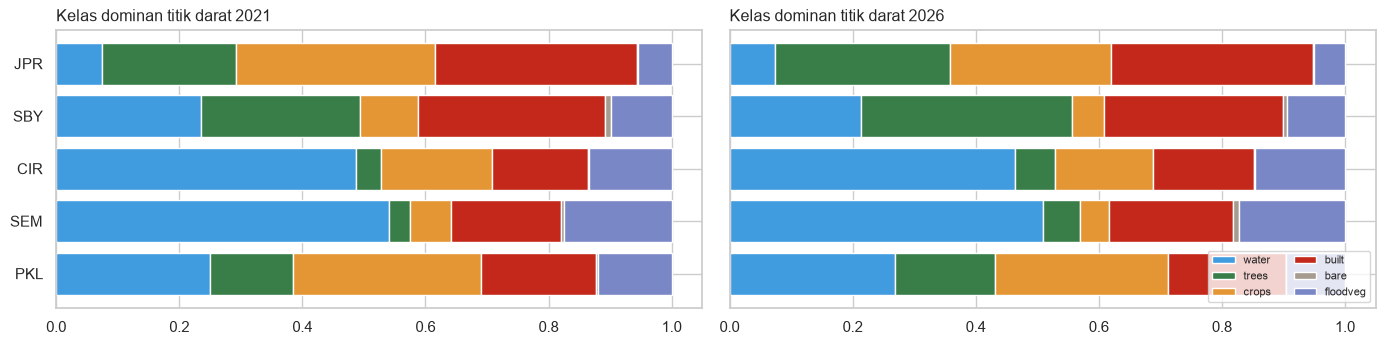

water  trees  crops  built   bare  floodveg
tahun wilayah                                             
2021  PKL      0.250  0.135  0.306  0.186  0.003     0.120
      SEM      0.541  0.034  0.067  0.179  0.004     0.176
      CIR      0.487  0.041  0.179  0.157  0.002     0.134
      SBY      0.235  0.259  0.093  0.303  0.011     0.098
      JPR      0.075  0.217  0.323  0.328  0.002     0.054
2026  PKL      0.269  0.161  0.281  0.191  0.001     0.095
      SEM      0.509  0.060  0.048  0.201  0.010     0.172
      CIR      0.464  0.065  0.159  0.165  0.002     0.146
      SBY      0.214  0.342  0.053  0.291  0.007     0.094
      JPR      0.073  0.285  0.262  0.328  0.002     0.050

In [15]:
komp = {}
for y, k in [(2021, 0), (2026, 5)]:
    dk = np.array(KELAS_DW)[DOM[:, 50:, k]]
    komp[y] = pd.DataFrame({r: pd.Series(dk[REG_I == r].ravel()).value_counts(normalize=True) for r in REG}).T[KELAS_DW].fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6), sharey=True)
warna_dw = {"water": "#419bdf", "trees": "#397d49", "crops": "#e49635", "built": "#c4281b", "bare": "#a59b8f", "floodveg": "#7a87c6"}
for a, y in zip(ax, [2021, 2026]):
    komp[y].plot.barh(stacked=True, ax=a, color=[warna_dw[k] for k in KELAS_DW], legend=a is ax[1], width=0.8)
    a.set_title(f"Kelas dominan titik darat {y}", loc="left")
ax[1].legend(fontsize=8, loc="lower right", ncol=2)
plt.tight_layout(); simpan("07_komposisi_darat"); plt.show()
tabel(pd.concat(komp, names=["tahun", "wilayah"]).round(3), "07_komposisi_darat")

### 7.2 Pola pengelolaan tambak dari MNDWI bulanan dan keterhubungan pasang

Titik **kandidat tambak** = titik darat yang kelas dominannya air pada ≥ 4 dari 6 tahun dan bukan mangrove (GMW
2021/2025, WorldCover 2021). Dua sinyal dipakai:

- **Kejadian pengeringan**: bulan basah (MNDWI > 0) yang diikuti bulan kering berikutnya yang teramati. Tambak yang
  dikelola dikuras berkala di antara siklus panen.
- **Keterhubungan pasang** (`tide_coupling`): selisih frekuensi genangan radar saat pasang dan saat surut. Air tambak
  berpematang utuh tidak mengikuti pasang; pematang jebol atau terbuka membuatnya ikut pasang.

Kandidat tambak: 195,542 titik (27% titik darat) di 2145 transek; dengan >= 36 bulan MNDWI teramati: 195,542


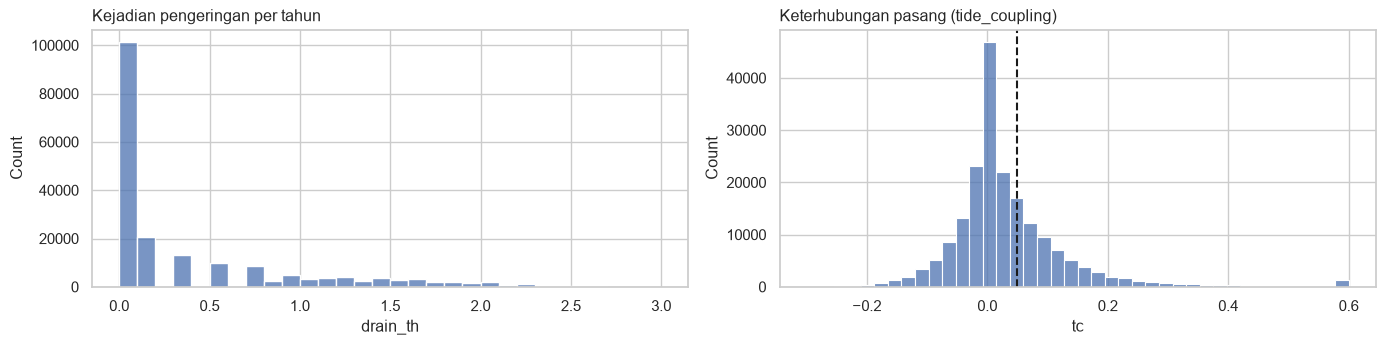

pola,dikeringkan + terhubung pasang,"dikeringkan berkala, tertutup","tergenang terus, tertutup",terhubung pasang,"tertutup, mulai bervegetasi"
wilayah,,,,,
PKL,0.05,0.23,0.50,0.18,0.03
SEM,0.03,0.17,0.52,0.22,0.06
CIR,0.07,0.34,0.34,0.22,0.04
SBY,0.08,0.21,0.40,0.28,0.03
JPR,0.07,0.41,0.25,0.23,0.04


Keseluruhan: {'tergenang terus, tertutup': 0.419, 'dikeringkan berkala, tertutup': 0.244, 'terhubung pasang': 0.236, 'dikeringkan + terhubung pasang': 0.062, 'tertutup, mulai bervegetasi': 0.039}


In [16]:
mang_any = g(2021) | g(2025) | (WC == 95)
KAND = darat & ((DOM == 0).sum(-1) >= 4) & ~mang_any
ii, jj = np.nonzero(KAND)
Mw = MNDWI[ii, jj, :]; Vw = np.isfinite(Mw); nvalid = Vw.sum(1)
drain = np.array([np.sum((s > 0)[:-1] & ~(s > 0)[1:]) for s in (Mw[k][Vw[k]] for k in range(len(ii)))])
drain_th = drain / np.maximum(nvalid / 12, 0.5)
nd_a = np.nanmedian(NDVI[ii, jj][:, TH_T == 2021], 1); nd_b = np.nanmedian(NDVI[ii, jj][:, TH_T == 2026], 1)
TP = pd.DataFrame(dict(wilayah=REG_I[ii], i=ii, j=jj, drain_th=drain_th, nvalid=nvalid, tc=TIDEC[ii, jj], dndvi=nd_b - nd_a))
TP = TP[TP.nvalid >= 36].reset_index(drop=True)
TP["pola"] = np.select(
    [(TP.drain_th >= 0.5) & (TP.tc <= 0.05), (TP.drain_th < 0.5) & (TP.tc > 0.05),
     (TP.drain_th < 0.5) & (TP.tc <= 0.05) & (TP.dndvi > 0.2), (TP.drain_th < 0.5) & (TP.tc <= 0.05)],
    ["dikeringkan berkala, tertutup", "terhubung pasang", "tertutup, mulai bervegetasi", "tergenang terus, tertutup"],
    "dikeringkan + terhubung pasang")
print(f"Kandidat tambak: {KAND.sum():,} titik ({KAND.sum() / (darat.sum() * N):.0%} titik darat) di {KAND.any(1).sum()} transek; "
      f"dengan >= 36 bulan MNDWI teramati: {len(TP):,}")
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
sns.histplot(TP.drain_th.clip(upper=3), bins=30, ax=ax[0]); ax[0].set_title("Kejadian pengeringan per tahun", loc="left")
sns.histplot(TP.tc.clip(-0.3, 0.6), bins=40, ax=ax[1]); ax[1].axvline(0.05, c="k", ls="--"); ax[1].set_title("Keterhubungan pasang (tide_coupling)", loc="left")
plt.tight_layout(); simpan("07_sinyal_tambak"); plt.show()
display(tabel(pd.crosstab(TP.wilayah, TP.pola, normalize="index").reindex(REG).round(2), "07_pola_tambak_per_wilayah"))
print("Keseluruhan:", TP.pola.value_counts(normalize=True).round(3).to_dict())

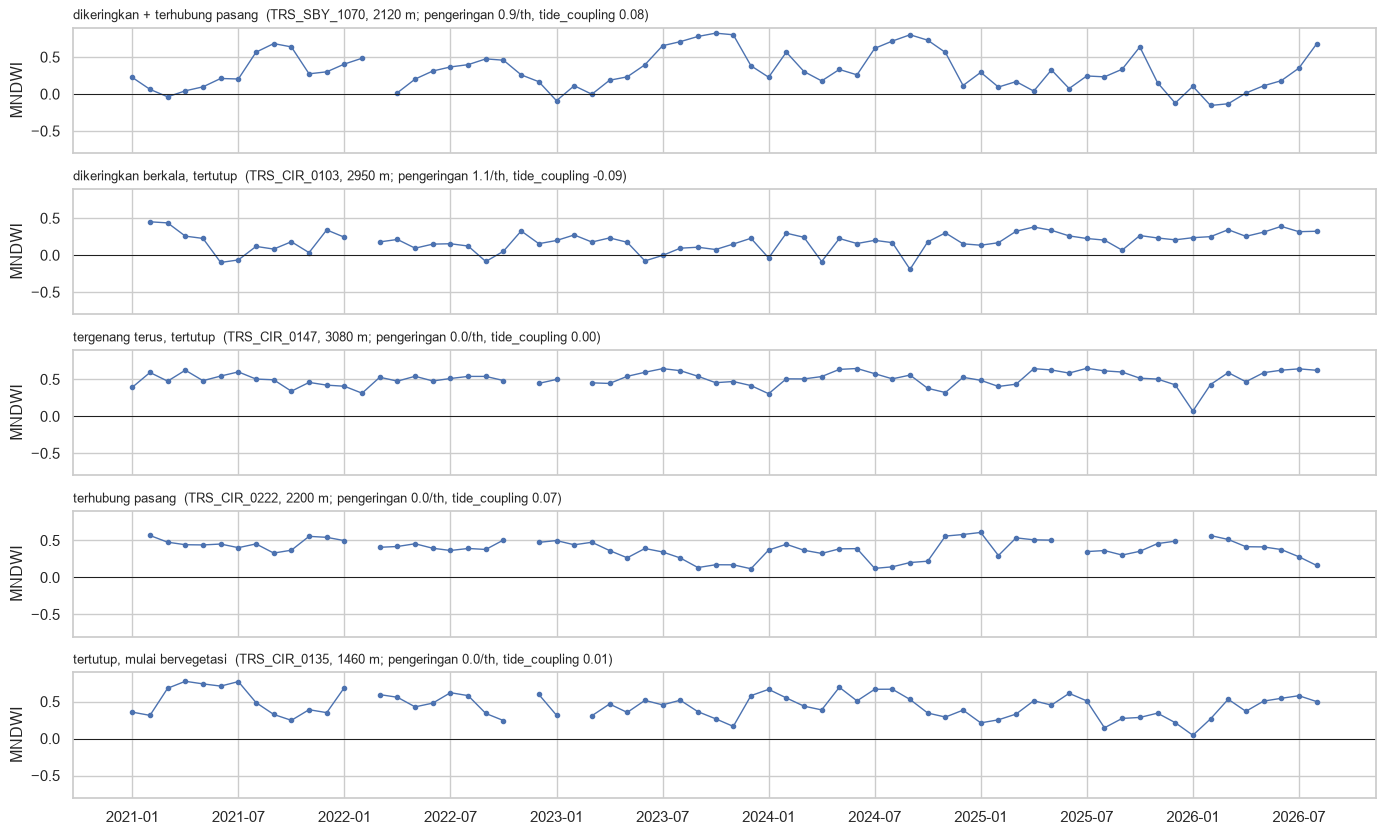

In [17]:
# contoh deret MNDWI satu titik per pola
rng = np.random.default_rng(3)
pol = TP.pola.unique()
fig, ax = plt.subplots(len(pol), 1, figsize=(14, 1.7 * len(pol)), sharex=True)
for a, p_ in zip(ax, sorted(pol)):
    r_ = TP[TP.pola == p_].iloc[rng.integers((TP.pola == p_).sum())]
    a.plot(np.arange(T), MNDWI[int(r_.i), int(r_.j)], "o-", ms=3, lw=1); a.axhline(0, c="k", lw=0.7)
    a.set_ylim(-0.8, 0.9); a.set_ylabel("MNDWI")
    a.set_title(f"{p_}  ({IDS[int(r_.i)]}, {int(r_.j) * STEP} m; pengeringan {r_.drain_th:.1f}/th, tide_coupling {r_.tc:.2f})", loc="left", fontsize=9)
ax[-1].set_xticks(np.arange(0, T, 6)); ax[-1].set_xticklabels(BULAN.astype(str)[::6])
plt.tight_layout(); simpan("07_contoh_deret_tambak"); plt.show()

### 7.3 Validasi visual status tambak (isian `validasi_tambak_ISI_MANUAL.csv`)

In [18]:
VT = md.validasi_tambak()
if VT is None or len(VT) == 0:
    print("Belum ada isian validasi visual. Bagian ini terisi otomatis setelah berkas diisi.")
else:
    idx_i = pd.Series(np.arange(N), index=IDS)
    VT["i"] = idx_i.loc[VT.transek_id].to_numpy(); VT["j"] = (VT.dist_m.astype(float) // STEP).astype(int)
    VT = VT.merge(TP[["i", "j", "pola"]], on=["i", "j"], how="left")
    yn = lambda s: s.fillna("").str.upper().str.startswith("Y")
    VT["visual"] = np.select([yn(VT.bukan_tambak), yn(VT.pematang_jebol), yn(VT.bervegetasi), yn(VT.pernah_kering)],
                             ["bukan tambak", "terhubung pasang", "tertutup, mulai bervegetasi", "dikeringkan berkala, tertutup"],
                             "tergenang terus, tertutup")
    print(f"{len(VT)} titik terisi")
    display(tabel(pd.crosstab(VT.pola.fillna("tidak masuk kandidat"), VT.visual, margins=True), "07_validasi_tambak"))

Belum ada isian validasi visual. Bagian ini terisi otomatis setelah berkas diisi.


**Interpretasi.**

- **SEM dan CIR adalah lanskap tambak**: air mendominasi 51% dan 46% titik darat pada 2026. Di SBY, kelas pohon naik
  (26% → 34%) dan sawah turun.
- Kandidat tambak meliputi **195.542 titik (27% titik darat) di 2.145 transek**. Pola sinyalnya:
  - **42% tergenang terus, tertutup pematang**;
  - **24% dikeringkan berkala, tertutup** (tambak aktif);
  - **24% terhubung pasang** (pematang jebol atau terbuka);
  - 6% dikeringkan sekaligus terhubung pasang;
  - 4% tertutup dan mulai bervegetasi.
- **SEM (52%) dan PKL (50%) paling banyak berkategori "tergenang terus"**. Di SEM ini sejalan dengan tambak yang tenggelam di
  zona amblesan. **CIR (34%) dan JPR (41%) paling banyak tambak aktif.**
- **Batasan.** Median bulanan bisa melewatkan pengeringan singkat (1–2 minggu), sehingga "tergenang terus" bisa berarti
  tambak tidak dikelola **atau** tambak bandeng yang jarang dikuras. Label tambak di notebook analisis karena itu disebut
  **indikasi**. Label ini belum divalidasi lapangan; Bagian 7.3 terisi otomatis bila validasi visual dilakukan.

## 8. Genangan pasang-surut per jenis lahan

`inund_freq` = proporsi akuisisi radar yang tergenang (VV < ambang), `tide_coupling` = selisih genangan saat pasang dan
surut. Keduanya menentukan **jendela hidroperiode** yang cocok untuk mangrove perintis (dihitung di notebook analisis).

In [19]:
laut = (DIST < LEN_SEA)[None, :] & ~mang_any
jenis_lahan = {"mangrove (GMW 2025)": g(2025), "depan pantai, bukan mangrove": laut & (DOM[:, :, 5] != 3),
               "kandidat tambak": KAND, "darat bervegetasi non-mangrove": darat & np.isin(DOM[:, :, 5], [1, 5]) & ~mang_any,
               "terbangun": darat & (DOM[:, :, 5] == 3)}
hid = pd.DataFrame({k: {"titik": int(M.sum()), "inund_freq median": np.nanmedian(INUND[M]), "inund_freq P90": np.nanquantile(INUND[M], 0.9),
                        "tide_coupling median": np.nanmedian(TIDEC[M]), "tide_coupling > 0,05": np.nanmean(TIDEC[M] > 0.05)}
                    for k, M in jenis_lahan.items()}).T
tabel(hid.round(3), "08_hidroperiode_per_lahan")

,titik,inund_freq median,inund_freq P90,tide_coupling median,"tide_coupling > 0,05"
mangrove (GMW 2025),49253.0,0.000,0.085,0.000,0.078
"depan pantai, bukan mangrove",114122.0,0.867,0.965,0.046,0.484
kandidat tambak,195542.0,0.393,0.921,0.011,0.298
darat bervegetasi non-mangrove,197389.0,0.000,0.122,0.000,0.050
terbangun,176559.0,0.000,0.000,0.000,0.004


**Interpretasi.**

- **Dataran di depan pantai** tergenang di sebagian besar akuisisi (median 0,87), dan 48% titiknya mengikuti pasang.
- **Tambak** tergenang sedang (median 0,39), dan hanya 30% yang mengikuti pasang. Air tambak dikendalikan pematang.
- **Di bawah kanopi mangrove, genangan hampir tidak terbaca (median 0)**. Radar VV tidak menembus kanopi rapat. Jadi
  jendela hidroperiode yang cocok untuk mangrove **tidak bisa diukur di bawah tegakan**, dan harus diukur di dataran
  pasang-surut terbuka di depan tepi mangrove. Pendekatan inilah yang dipakai di notebook analisis.

## 9. Daftar masalah data dan penanganannya

Tabel ini merangkum Bagian 2–8. Kolom *penanganan* menunjuk bagian notebook analisis
(`02_Analisis_Coastal_Squeeze.ipynb`) yang menyelesaikannya.

In [20]:
masalah = pd.DataFrame([
    ("M1", "Radar VH kosong terstruktur", f"SBY {int(ring.loc['SBY', 'bulan VH kosong >50%'])} dari {T} bulan kosong karena satu orbit per transek; "
           f"citra dari orbit/lintasan lain ada (bulan tanpa citra sama sekali: SBY {orb_tab.loc['SBY', 'bulan_tanpa_citra_sama_sekali']})",
     "tepi tidak terukur berbulan-bulan", "paket profil_s1m (semua orbit) bila tersedia (Bag. 2); Kalman melewati bulan kosong (Bag. 5)"),
    ("M2", "NDVI kosong musiman (awan)", f"hingga {miss_ndvi.max().max():.0%} titik kosong pada puncak musim hujan",
     "tepi palsu bila tegakan tertutup awan", "bulan dipakai hanya bila zona pencarian cukup teramati; filter pencilan (Bag. 3.4)"),
    ("M3", "Ambang VH panduan terlalu tinggi", "−14 dB berada di atas median VH mangrove",
     "separuh tegakan gagal terdeteksi", "ambang dikalibrasi (Bag. 3.3)"),
    ("M4", "NDVI+VH tidak membedakan mangrove dari pohon darat", "sebaran mangrove dan pohon darat bertumpang tindih (Bag. 4)",
     "keberadaan mangrove dari sinyal saja terlalu tinggi", "keberadaan dari GMW/WorldCover, dikonfirmasi Sentinel (Bag. 3.1)"),
    ("M5", "WorldCover melewatkan mangrove", f"{int((GRUP == 'B: hanya GMW').sum())} transek bermangrove menurut GMW saja; sinyal Sentinel mendukung GMW "
           f"(lolos {adj.loc['B: hanya GMW', 'lolos kriteria']:.0%} vs {adj.loc['A: keduanya', 'lolos kriteria']:.0%}); "
           f"{int((GRUP == 'C: hanya WorldCover').sum())} transek hanya WorldCover dengan sinyal lemah",
     "domain berbasis WorldCover 2021 terlalu sempit", "domain dari GMW ∪ WorldCover dengan konfirmasi Sentinel (Bag. 3.1)"),
    ("M6", "Mangrove berubah besar 2021–2025", f"{BARU.sum():,} titik baru vs {HILANG.sum():,} hilang; perubahan dikonfirmasi lintasan NDVI/VH",
     "domain satu tahun (2021) melewatkan ekspansi dan kehilangan", "domain dan batas pencarian dinamis (Bag. 3.1–3.2), layer dinamika (Bag. 4.1)"),
    ("M7", "Resolusi dan kualitas GMW", "30 m (3 titik transek per piksel); sebelum 2000 sebagian diisi dari tahun lain",
     "laju tepi GMW kasar; tren pra-2000 tidak andal", "laju jangka panjang GMW 2015–2025 dengan penduga Theil–Sen (Bag. 4.2)"),
    ("M8", "Amblesan kosong atau diisi", f"{TR.subs_cm_th.isna().mean():.0%} transek kosong; "
           f"{(TR.subs_sumber == 'tetangga').mean():.0%} diisi tetangga, {(TR.subs_sumber == 'darat').mean():.0%} memakai titik darat",
     "galat ukur pada kovariat utama → koefisien mengecil", "galat per sumber (Bag. 6.1 notebook ini) dipakai di uji galat ukur SIMEX (Bag. 6.3)"),
    ("M9", "Periode InSAR 2017–2023", "hanya beririsan 2021–2023 dengan data tepi", "amblesan dianggap laju persisten", "dinyatakan sebagai asumsi"),
    ("M10", "Penghalang > 3,5 km tidak teramati", "transek hanya 3 km ke darat", "ruang gerak tersensor kanan (batas bawah)",
     "P(Closed) dilaporkan sebagai batas atas (Bag. 7.2)"),
    ("M11", "Kedipan kelas terbangun Dynamic World", f"{(kedip & darat).sum() / (pernah & darat).sum():.0%} titik yang pernah terbangun berkedip",
     "bangunan baru dan penghalang berlebih", "syarat tetap dua tahun (Bag. 3.6–3.7)"),
    ("M12", "Status tambak dari median bulanan", "pengeringan singkat (1–2 minggu) bisa terlewat; 'tergenang terus' ambigu",
     "tambak aktif bisa terbaca terbengkalai", "label disebut 'indikasi' (Bag. 3.7); belum divalidasi lapangan (Bag. 7.3 bila validasi dilakukan)"),
    ("M13", "Transek multi-persilangan pantai", f"{(TR.n_silang_pantai > 1).mean():.0%} transek", "tepi bisa melompat antar garis pantai",
     "uji ulang tanpa transek ini (Bag. 10.3)"),
    ("M14", "Jangkauan laut transek 500 m", "mangrove yang hilang ke laut lebih jauh (mis. Sayung) di luar transek",
     "kehilangan historis di pantai yang sudah mundur tidak terukur", "dinyatakan sebagai keterbatasan"),
    ("M15", "Penduduk 2025–2026 proyeksi WorldPop", "bukan sensus", "PERI memakai proyeksi", "dinyatakan sebagai asumsi"),
], columns=["kode", "masalah", "bukti", "dampak", "penanganan di notebook 02"]).set_index("kode")
tabel(masalah, "09_masalah_data")

,masalah,bukti,dampak,penanganan di notebook 02
kode,,,,
M1,Radar VH kosong terstruktur,SBY 27 dari 68 bulan kosong karena satu orbit ...,tepi tidak terukur berbulan-bulan,paket profil_s1m (semua orbit) bila tersedia (...
M2,NDVI kosong musiman (awan),hingga 96% titik kosong pada puncak musim hujan,tepi palsu bila tegakan tertutup awan,bulan dipakai hanya bila zona pencarian cukup ...
M3,Ambang VH panduan terlalu tinggi,−14 dB berada di atas median VH mangrove,separuh tegakan gagal terdeteksi,ambang dikalibrasi (Bag. 3.3)
M4,NDVI+VH tidak membedakan mangrove dari pohon d...,sebaran mangrove dan pohon darat bertumpang ti...,keberadaan mangrove dari sinyal saja terlalu t...,"keberadaan dari GMW/WorldCover, dikonfirmasi S..."
M5,WorldCover melewatkan mangrove,357 transek bermangrove menurut GMW saja; siny...,domain berbasis WorldCover 2021 terlalu sempit,domain dari GMW ∪ WorldCover dengan konfirmasi...
M6,Mangrove berubah besar 2021–2025,"10,523 titik baru vs 1,842 hilang; perubahan d...",domain satu tahun (2021) melewatkan ekspansi d...,domain dan batas pencarian dinamis (Bag. 3.1–3...
M7,Resolusi dan kualitas GMW,30 m (3 titik transek per piksel); sebelum 200...,laju tepi GMW kasar; tren pra-2000 tidak andal,laju jangka panjang GMW 2015–2025 dengan pendu...
M8,Amblesan kosong atau diisi,"10% transek kosong; 11% diisi tetangga, 22% me...",galat ukur pada kovariat utama → koefisien men...,galat per sumber (Bag. 6.1 notebook ini) dipak...
M9,Periode InSAR 2017–2023,hanya beririsan 2021–2023 dengan data tepi,amblesan dianggap laju persisten,dinyatakan sebagai asumsi


## Ringkasan untuk notebook analisis

1. **Keberadaan mangrove**: pakai GMW ∪ WorldCover dengan konfirmasi Sentinel; waspadai PKL (M4, M5).
2. **Mangrove dinamis**: ekspansi 10,5 ribu titik dan kehilangan 1,8 ribu titik dalam 2021–2025 terkonfirmasi, sehingga
   domain dan batas pencarian tepi harus dinamis (M6).
3. **Radar**: celah terbesar berasal dari pilihan orbit, bukan dari sensor. Paket multi-orbit `profil_s1m` menutupnya:
   bulan kosong SBY turun dari 27 ke 3 (M1).
4. **Amblesan**: kovariat utama dengan galat terukur, kecil secara absolut tetapi nyata, dan cenderung meremehkan
   amblesan ekstrem (M8).
5. **Tambak**: pola pengelolaan bisa dibaca dari MNDWI bulanan dan keterhubungan pasang, dengan status "indikasi"
   (M12).
6. **Bangunan baru**: harus disaring kedipannya. Tanpa saringan, konversi terhitung dua kali lipat (M11).